# 📊 Emotion Detection - Exploratory Data Analysis (EDA) & Model Testing

This notebook explores the FER2013 dataset, visualizes the class distribution, and tests the trained CNN model on random samples to verify its performance.

---

## Import Libraries


In [6]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

# Set a clean plot style
sns.set_style("darkgrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Get the current working directory (should be /notebooks if opened here)
# Go up one level to the project root
project_root = os.path.dirname(os.getcwd())  
data_path = os.path.join(project_root, 'data', 'fer2013.csv')

# Load the CSV
df = pd.read_csv(data_path)
print(f"Dataset loaded successfully! Shape: {df.shape}")
print(df.head())

Dataset loaded successfully! Shape: (35887, 3)
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


C:\Users\kapta\AppData\Local\Temp\ipykernel_20240\644829940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion_label', data=df, order=emotion_labels, palette='viridis')


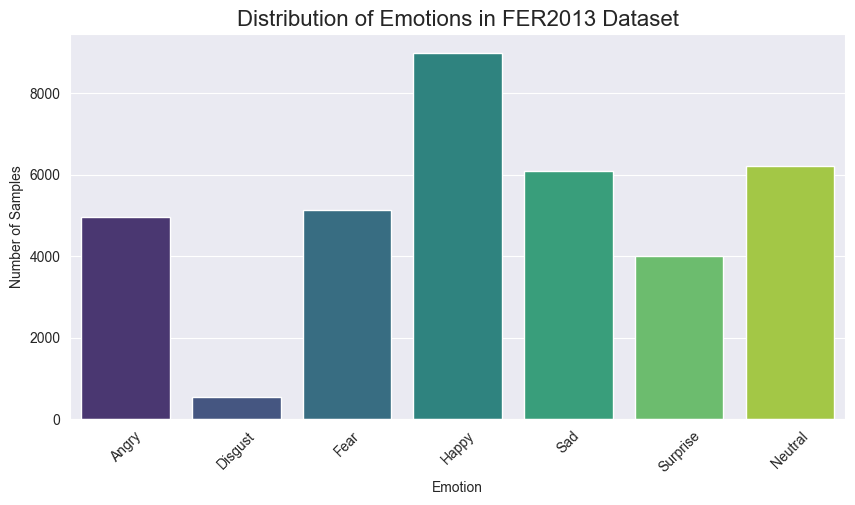


Sample counts per emotion:
emotion_label
Happy       8989
Neutral     6198
Sad         6077
Fear        5121
Angry       4953
Surprise    4002
Disgust      547
Name: count, dtype: int64


In [8]:
# Map numeric emotion labels to actual names
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
df['emotion_label'] = df['emotion'].map(lambda x: emotion_labels[x])

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='emotion_label', data=df, order=emotion_labels, palette='viridis')
plt.title('Distribution of Emotions in FER2013 Dataset', fontsize=16)
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

# Print exact numbers
print("\nSample counts per emotion:")
print(df['emotion_label'].value_counts())

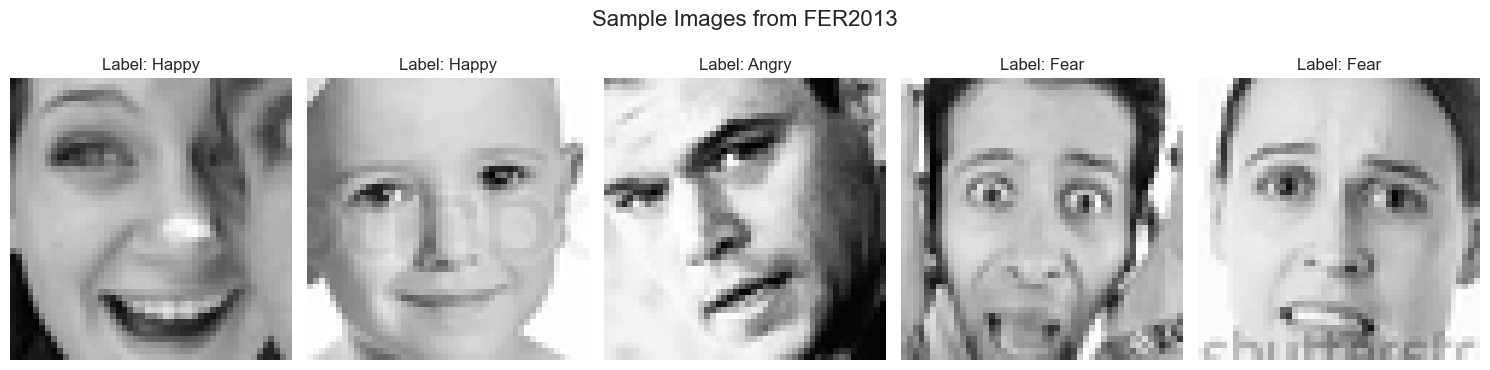

In [9]:
# Pick 5 random rows
sample_rows = df.sample(n=5)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, (idx, row) in enumerate(sample_rows.iterrows()):
    pixels = list(map(int, row['pixels'].split()))
    image = np.array(pixels).reshape(48, 48)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {row['emotion_label']}")
    axes[i].axis('off')
    
plt.suptitle('Sample Images from FER2013', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
model_path = os.path.join(project_root, 'models', 'emotion_model.h5')
model = load_model(model_path)
print("Model loaded successfully!")
model.summary()  # Displays the architecture

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,913 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

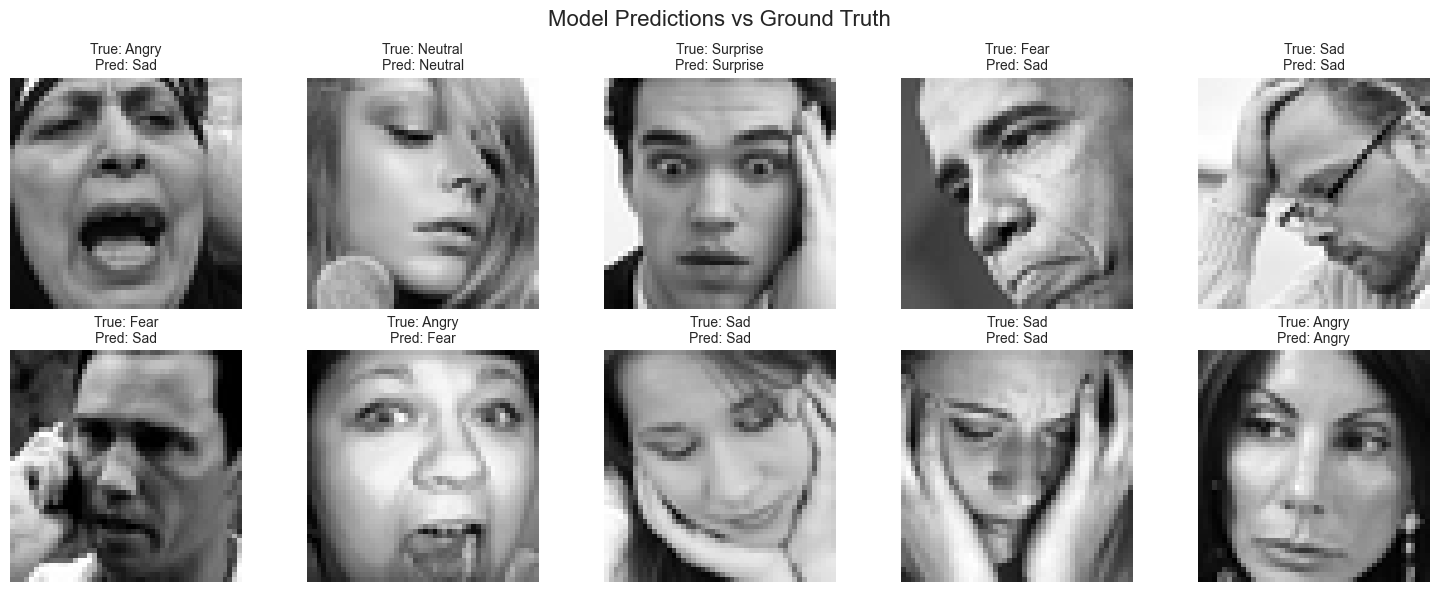


✅ Accuracy on these 10 random samples: 60.00%


In [11]:
# Select 10 random samples
test_samples = df.sample(n=10)

# Prepare the images
X_test = []
true_labels = []
for _, row in test_samples.iterrows():
    pixels = list(map(int, row['pixels'].split()))
    img = np.array(pixels).reshape(48, 48, 1) / 255.0  # Normalize
    X_test.append(img)
    true_labels.append(row['emotion_label'])

X_test = np.array(X_test)

# Get model predictions
predictions = model.predict(X_test, verbose=0)
predicted_labels = [emotion_labels[np.argmax(p)] for p in predictions]

# Display the results
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(48, 48), cmap='gray')
    ax.set_title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}", fontsize=10)
    ax.axis('off')
    
plt.suptitle('Model Predictions vs Ground Truth', fontsize=16)
plt.tight_layout()
plt.show()

# Print a classification summary
from sklearn.metrics import accuracy_score
true_numeric = [emotion_labels.index(label) for label in true_labels]
pred_numeric = [np.argmax(p) for p in predictions]
acc = accuracy_score(true_numeric, pred_numeric)
print(f"\n✅ Accuracy on these 10 random samples: {acc * 100:.2f}%")


---

### 📝 How to use this notebook:
1. **Save** the file (`Ctrl+S`).
2. In VS Code, click the **"Run All"** button at the top of the notebook, or run each cell one by one.
3. You will see beautiful graphs pop up showing the data distribution and a grid of images comparing your model's predictions to the truth. 

This notebook proves to interviewers that you know how to **analyze, visualize, and evaluate** your model, which is the mark of a great data scientist/ML engineer! 🚀